# Predicting Letters

1.   Trigram prediction, maximum likelihood and cross-entropy loss function
2.   Multi layer perceptron, backpropagation and gradient descent
3.   Recurrent neural networks
4.   Attention please
5.   Mini-GPT :) <3

## Setup

In [ ]:
import os
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

!wget http://mattmahoney.net/dc/text8.zip
!unzip text8.zip

--2026-04-16 19:47:52--  http://mattmahoney.net/dc/text8.zip
Resolving mattmahoney.net (mattmahoney.net)... 20.119.76.151
Connecting to mattmahoney.net (mattmahoney.net)|20.119.76.151|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31344016 (30M) [application/zip]
Saving to: ‘text8.zip.1’

text8.zip.1         100%[===================>]  29.89M   163MB/s    in 0.2s    

2026-04-16 19:47:52 (163 MB/s) - ‘text8.zip.1’ saved [31344016/31344016]

Archive:  text8.zip
replace text8? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: text8                   


In [ ]:
# I will define the file path
file_path = 'text8'

# Control step 1: Check if the file exists before attempting to read
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file {file_path} was not found. I need to run the wget command first.")

# I need to read the raw text file
with open(file_path, 'r') as f:
    full_text = f.read()

# Control step 2: Verify the total length of the raw data
print(f"Total characters in full dataset: {len(full_text)}")

# I will slice exactly 10% of the text for my training subset
subset_size = int(len(full_text) * 0.10)
train_text = full_text[:subset_size]

# Control step 3: Verify the subset length and inspect the data format
print(f"Characters in my training subset: {len(train_text)}")
print(f"Sample of the first 50 characters: '{train_text[:50]}'")

Total characters in full dataset: 100000000
Characters in my training subset: 10000000
Sample of the first 50 characters: ' anarchism originated as a term of abuse first use'


Total unique characters: 27
Unique characters list: [' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


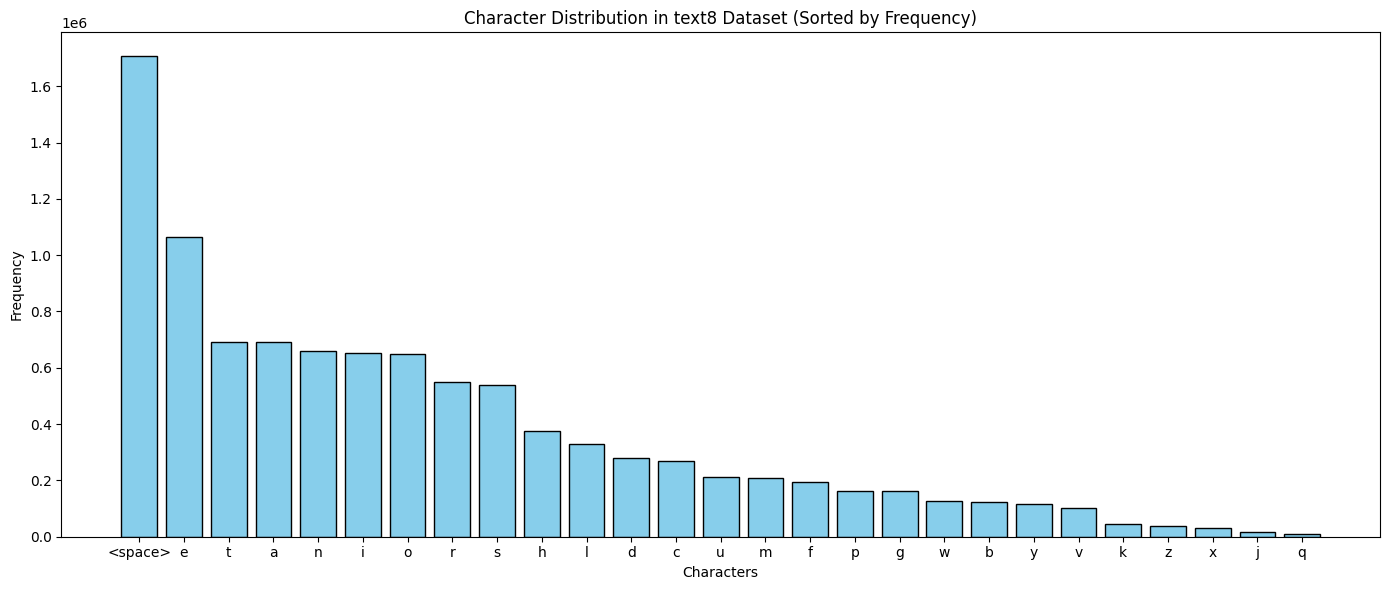

In [ ]:
# Control step 1: Extract and verify the unique characters
# Converting to a set removes duplicates, then I sort it for readability
unique_chars = sorted(list(set(train_text)))
print(f"Total unique characters: {len(unique_chars)}")
print(f"Unique characters list: {repr(unique_chars)}")

# Control step 2: Count the occurrences of each character
# collections.Counter is highly optimized for this task
char_counts = collections.Counter(train_text)

# I will sort the counts in descending order to make the bar chart readable
sorted_counts = char_counts.most_common()

# Extracting labels and values for the plot
# I'm replacing the space character with '<space>' so it shows up clearly on the axis
labels = [char if char != ' ' else '<space>' for char, count in sorted_counts]
values = [count for char, count in sorted_counts]

# Plotting the visual distribution
plt.figure(figsize=(14, 6))
plt.bar(labels, values, color='skyblue', edgecolor='black')
plt.title('Character Distribution in text8 Dataset (Sorted by Frequency)')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.xticks(rotation=0)

# Ensuring labels do not overlap and the layout is clean
plt.tight_layout()
plt.show()

## 1- Trigram, prediction, maximum likelihood and cross-entropy loss function

In [ ]:
# Predicting trigrams using a matrix

# Create a mapping with the latters ("space":0, "a":1, ... "z":27)
# Split the whole text data into trigrams (shift 1 char at a time)
# Create a 27x27x27 matrix
# Fill the matrix according to the indicies of the trigrams "abc" -> matrix[i=1,j=2,k=3] += 1
# Visualize the matrix

# hilal

# Split it like this
# hil
# ila
# lal

In [ ]:
chars = sorted(list(set(train_text)))

# We sort to ensure ' ' is index 0, 'a' is 1, ..., 'z' is 26
chars = sorted(list(set(train_text)))
stoi = {s: i for i, s in enumerate(chars)} # String to Integer mapping
itos = {i: s for s, i in stoi.items()}     # Integer to String mapping

print(f"Mapping complete. 'a' is {stoi['a']}, 'z' is {stoi['z']}, '<space>' is {stoi[' ']}")

Mapping complete. 'a' is 1, 'z' is 26, '<space>' is 0


In [ ]:
stoi

{' ': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [ ]:
M = np.zeros((27, 27, 27), dtype=np.int32)
type(train_text)
print("Filling the 3D matrix. This will take just a few seconds...")
for ch1, ch2, ch3 in zip(train_text, train_text[1:], train_text[2:]):
    idx1, idx2, idx3 = stoi[ch1], stoi[ch2], stoi[ch3]
    M[idx1, idx2, idx3] += 1

print(f"Matrix filled! Total trigrams processed: {M.sum():,}")

Filling the 3D matrix. This will take just a few seconds...
Matrix filled! Total trigrams processed: 9,999,998


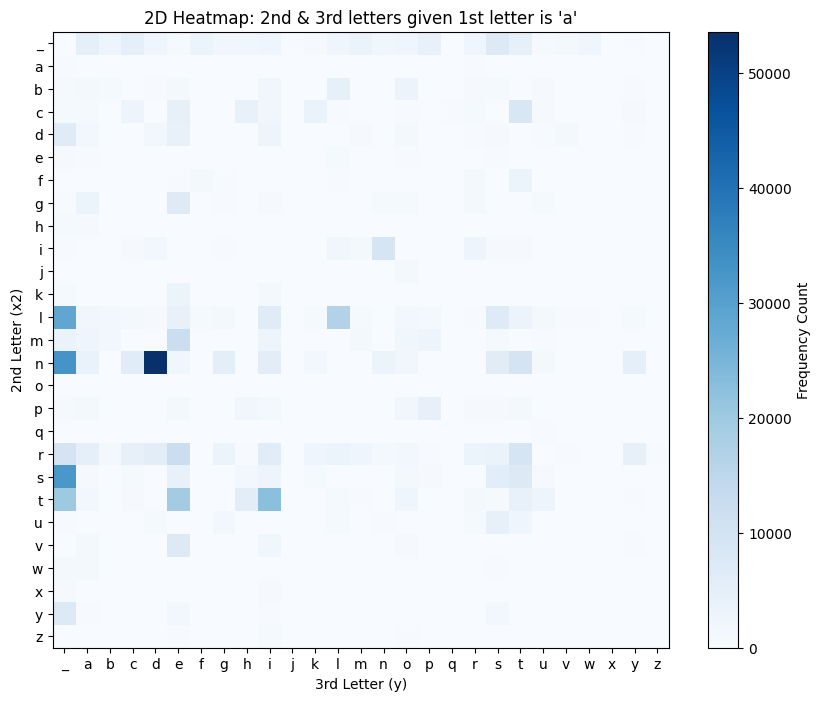

In [ ]:
# ---------------------------------------------------------
# VISUALIZATION 1: Matrix Slicing (2D Heatmap)
# Let's fix the first letter as 't' and look at the transitions for the 2nd and 3rd
# ---------------------------------------------------------
fixed_char = 'a'
fixed_idx = stoi[fixed_char]
slice_2d = M[fixed_idx, :, :] # Slice the 3D array into a 27x27 2D array

plt.figure(figsize=(10, 8))
plt.imshow(slice_2d, cmap='Blues')
plt.title(f"2D Heatmap: 2nd & 3rd letters given 1st letter is '{fixed_char}'")
# Replace spaces with '_' for axis readability
display_chars = [c if c != ' ' else '_' for c in chars]
plt.xticks(range(27), display_chars)
plt.yticks(range(27), display_chars)
plt.xlabel('3rd Letter (y)')
plt.ylabel('2nd Letter (x2)')
plt.colorbar(label='Frequency Count')
plt.show()

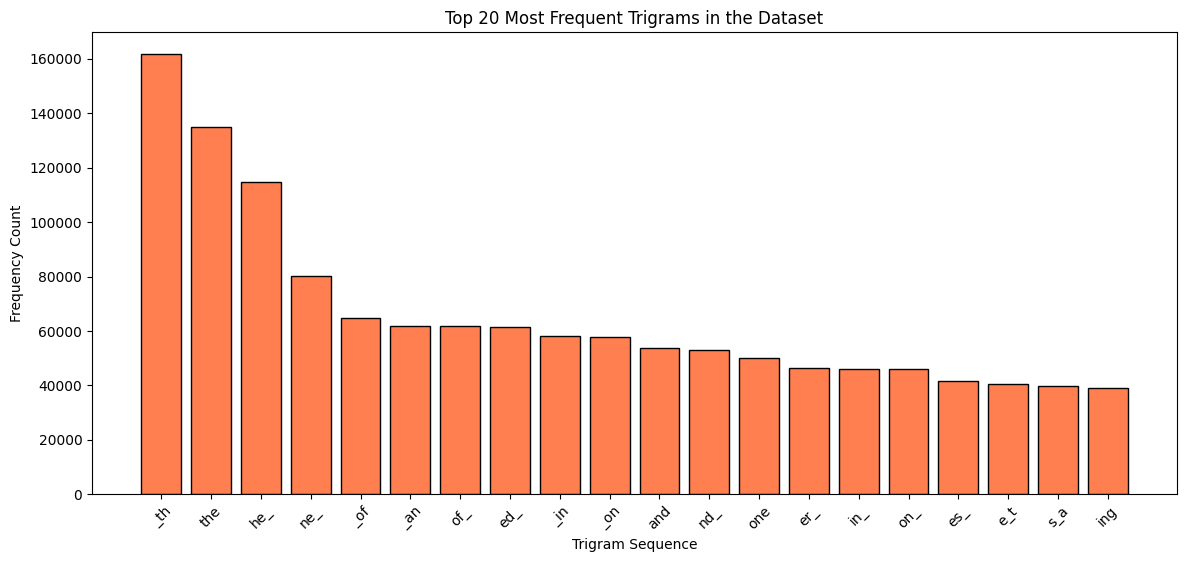

In [ ]:
# ---------------------------------------------------------
# VISUALIZATION 2: Top-K Trigram Distribution (1D Bar Chart)
# ---------------------------------------------------------
# Flatten the matrix to 1D to easily sort and find the max values
flat_M = M.flatten()
top_20_indices = np.argsort(flat_M)[-20:][::-1] # Get indices of top 20, descending
top_20_counts = flat_M[top_20_indices]

trigram_labels = []
for flat_idx in top_20_indices:
    # np.unravel_index converts the 1D flat index back to 3D coordinates (i, j, k)
    i, j, k = np.unravel_index(flat_idx, (27, 27, 27))
    # Combine back to string, replacing space with '_' to make it visible
    trigram = (itos[i] + itos[j] + itos[k]).replace(' ', '_')
    trigram_labels.append(trigram)

plt.figure(figsize=(14, 6))
plt.bar(trigram_labels, top_20_counts, color='coral', edgecolor='black')
plt.title('Top 20 Most Frequent Trigrams in the Dataset')
plt.xlabel('Trigram Sequence')
plt.ylabel('Frequency Count')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_50288/3901630198.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


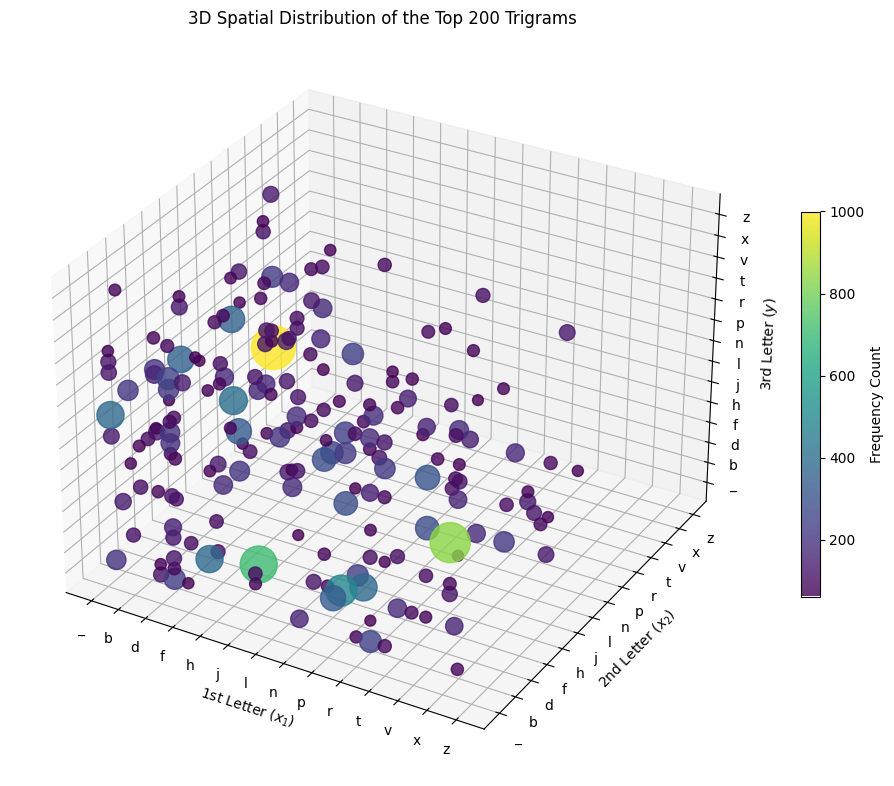

In [ ]:
# ---------------------------------------------------------
# VISUALIZATION 3: Filtered 3D Scatter Plot
# ---------------------------------------------------------
# Plotting all 19,683 points is an unreadable mess.
# We filter to show only the top 200 most frequent combinations.
K = 200
top_k_indices = np.argsort(flat_M)[-K:]

x_vals, y_vals, z_vals = [], [], []
sizes = []

for flat_idx in top_k_indices:
    i, j, k = np.unravel_index(flat_idx, (27, 27, 27))
    x_vals.append(i)
    y_vals.append(j)
    z_vals.append(k)
    sizes.append(flat_M[flat_idx])

# Normalize sizes so the largest dot is prominent but not screen-filling
sizes = np.array(sizes)
sizes_normalized = (sizes / sizes.max()) * 1000

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(projection='3d')

# Color and size represent the frequency of the trigram
scatter = ax.scatter(x_vals, y_vals, z_vals, s=sizes_normalized, c=sizes_normalized, cmap='viridis', alpha=0.8)

# Set ticks (every 2nd character to prevent overlapping text)
ax.set_xticks(range(0, 27, 2))
ax.set_xticklabels([display_chars[i] for i in range(0, 27, 2)])
ax.set_yticks(range(0, 27, 2))
ax.set_yticklabels([display_chars[i] for i in range(0, 27, 2)])
ax.set_zticks(range(0, 27, 2))
ax.set_zticklabels([display_chars[i] for i in range(0, 27, 2)])

ax.set_xlabel('1st Letter ($x_1$)')
ax.set_ylabel('2nd Letter ($x_2$)')
ax.set_zlabel('3rd Letter ($y$)')
ax.set_title(f'3D Spatial Distribution of the Top {K} Trigrams')
fig.colorbar(scatter, label='Frequency Count', shrink=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# By adding 1 to every count in the matrix, I ensure there are no zero-sums.
# This assigns a tiny non-zero probability to unseen combinations, preventing crashes.
M_smooth = M + 1
row_sums_smooth = M_smooth.sum(axis=2, keepdims=True)

# I will convert the frequency counts into a probability distribution matrix (P)
P = M_smooth / row_sums_smooth


def generate_text(seed, length=100):
    """
    Generates text using the trained probability matrix.
    """

    # I will initialize the output sequence with my seed
    out = [seed[0], seed[1]]

    # I will iteratively generate the next character
    for _ in range(length):
        ch1, ch2 = out[-2], out[-1]
        idx1, idx2 = stoi[ch1], stoi[ch2]

        # Extract the probability distribution for the next character
        p_dist = P[idx1, idx2, :]

        # I will sample the next index based on the calculated probabilities.
        # Sampling (rather than always taking the max) adds necessary variance to text generation.
        next_idx = np.random.choice(27, p=p_dist) #np.argmax(p_dist)

        # Append the new character to my output list
        out.append(itos[next_idx])

    return ''.join(out)

# Generating outputs
print("\n--- Output generated from seed 'th' ---")
print(generate_text('th', 150))

print("\n--- Output generated from seed 'an' ---")
print(generate_text('an', 150))


--- Output generated from seed 'th' ---
the n focke one comem of b th afte kin exitaker on on twounwars welplateary and ing pub wil phimedgerlack the onnalgovirks thre y of the and by cided ap

--- Output generated from seed 'an' ---
ans wity bove or sucepro on ablaczed tder naweevat nin mis ents drims chent thould such u siummor fiverwas wa theignefout manate hes humbly butor as of 


In [ ]:
# 1. Extract the ground truth validation set
# We take the 10,000 characters immediately following our 10% training data
val_start = int(len(full_text) * 0.10)
val_end = val_start + 10000
val_text = full_text[val_start:val_end]

print(f"Validation set size: {len(val_text)} characters")

# 2. Define the Cross-Entropy Loss function
def calculate_cross_entropy(text, prob_matrix, is_random=False):
    total_loss = 0.0
    n_predictions = 0

    # We iterate through the 10,000 characters
    for ch1, ch2, target in zip(text, text[1:], text[2:]):
        # We must skip characters that somehow aren't in our vocabulary (safety control)
        if ch1 not in stoi or ch2 not in stoi or target not in stoi:
            continue

        idx1, idx2, target_idx = stoi[ch1], stoi[ch2], stoi[target]

        if is_random:
            # A completely random model assigns a flat 1/27 probability to every letter
            prob = 1.0 / 27.0
        else:
            # Our model looks up the probability of the true target given the past 2 letters
            prob = prob_matrix[idx1, idx2, target_idx]

        # Cross-Entropy is the negative log of the predicted probability of the TRUE class
        total_loss += -np.log(prob)
        n_predictions += 1

    # Return the average loss per character
    return total_loss / n_predictions

# 3. Calculate metrics
print("\nRunning evaluation on 10,000 unseen characters...")

# Random Guessing (Baseline)
random_loss = calculate_cross_entropy(val_text, P, is_random=True)

# Trained Trigram Model
trigram_loss = calculate_cross_entropy(val_text, P, is_random=False)

# 4. Display the results
print("\n--- Final Cross-Entropy Loss Results ---")
print(f"Random Guessing Baseline: {random_loss:.4f}")
print(f"Trained Trigram Model:    {trigram_loss:.4f}")

# Calculate how many times better the model is (Perplexity ratio)
random_perplexity = np.exp(random_loss)
trigram_perplexity = np.exp(trigram_loss)

print("\n--- Perplexity (Intuitive Confusion Metric) ---")
print(f"Random Model chooses between ~{random_perplexity:.0f} characters.")
print(f"Trigram Model narrows it down to ~{trigram_perplexity:.1f} characters.")

Validation set size: 10000 characters

Running evaluation on 10,000 unseen characters...

--- Final Cross-Entropy Loss Results ---
Random Guessing Baseline: 3.2958
Trained Trigram Model:    1.9755

--- Perplexity (Intuitive Confusion Metric) ---
Random Model chooses between ~27 characters.
Trigram Model narrows it down to ~7.2 characters.


## 2- Multi-layer perceptron (MLP), backpropagation and gradient descent

#### Data Setup

In [ ]:
# Data Preperation
text = train_text

# --- 1. Build Vocabulary ---
chars = sorted(list(set(text)))
vocab_size = len(chars) # Should be 27 (a-z + space)
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}

# --- 2. Create Trigrams (Context=2, Target=1) ---
# We want to predict char[i+2] given char[i] and char[i+1]
xs_int = []
ys_int = []
for i in range(len(text) - 2):
    xs_int.append([char_to_int[text[i]], char_to_int[text[i+1]]])
    ys_int.append(char_to_int[text[i+2]])

# --- 3. Train/Test Split (80/20) ---
split_idx = int(len(xs_int) * 0.8)
train_xs, test_xs = xs_int[:split_idx], xs_int[split_idx:]
train_ys, test_ys = ys_int[:split_idx], ys_int[split_idx:]

# --- 4. Helper to generate a One-Hot Batch ---
def get_batch(xs, ys, batch_size=10):
    # Grab the first 'batch_size' examples for this demonstration
    x_batch = xs[:batch_size]
    y_batch = ys[:batch_size]

    # Initialize zero matrices for one-hot encoding
    # X shape: (batch_size, 54) -> 27 features for char1 + 27 features for char2
    X_onehot = np.zeros((batch_size, vocab_size * 2))
    # Y shape: (batch_size, 27)
    Y_onehot = np.zeros((batch_size, vocab_size))

    for i in range(batch_size):
        char1_idx, char2_idx = x_batch[i]
        target_idx = y_batch[i]

        # Set the 1s
        X_onehot[i, char1_idx] = 1.0                     # First character
        X_onehot[i, vocab_size + char2_idx] = 1.0        # Second character (offset by 27)
        Y_onehot[i, target_idx] = 1.0                    # Target label

    return X_onehot, Y_onehot

# Fetch exactly 10 examples to match your requirement
X, Y = get_batch(train_xs, train_ys, batch_size=10)

print(f"Input X shape: {X.shape}") # Expected: (10, 54)
print(f"Labels Y shape: {Y.shape}") # Expected: (10, 27)

Input X shape: (10, 54)
Labels Y shape: (10, 27)


#### Building MLP

In [ ]:
# 1. Configuration
batch_size = 10000
n = batch_size
input_size = 54   # 26 letters + space, times 2 characters
hidden_size = 128
hidden_size2 = 64
output_size = 27  # Predict 1 character out of 27
learning_rate = 0.2

# 2. Initialize Parameters (Weights and Biases)
# Using standard normal distribution scaled down for stability
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, hidden_size2) * 0.01
b2 = np.zeros((1, hidden_size2))

W3 = np.random.randn(hidden_size2, output_size) * 0.01
b3 = np.zeros((1, output_size))

# 3. Define Functions (Updated for batch processing)
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [ ]:
# Get the data
X, Y = get_batch(train_xs, train_ys, batch_size=batch_size)
print(X.shape)
print(Y.shape)

(10000, 54)
(10000, 27)


In [ ]:
training_loss_history = []

In [ ]:
for i in range(1000):
  # ==========================================
  # 1. FORWARD PASS
  # ==========================================
  Z1 = np.dot(X, W1) + b1
  A1 = relu(Z1)

  Z2 = np.dot(A1, W2) + b2
  A2 = relu(Z2)

  Z3 = np.dot(A2, W3) + b3
  Y_hat = softmax(Z3)

  # Calculate Loss
  epsilon = 1e-12
  cross_entropy_loss = -np.sum(Y * np.log(Y_hat + epsilon))*(1/n)
  if(i % 100 == 0):
     print(f"Cross-Entropy Loss: {cross_entropy_loss:.4f}")
  # ==========================================
  # 2. BACKWARD PASS
  # ==========================================
  dZ3 = (Y_hat - Y) / n
  dW3 = np.dot(A2.T, dZ3)
  db3 = np.sum(dZ3, axis=0, keepdims=True)
  dA2 = np.dot(dZ3, W3.T)

  dZ2 = dA2 * (Z2 > 0)
  dW2 = np.dot(A1.T, dZ2)
  db2 = np.sum(dZ2, axis=0, keepdims=True)
  dA1 = np.dot(dZ2, W2.T)

  dZ1 = dA1 * (Z1 > 0)
  dW1 = np.dot(X.T, dZ1)
  db1 = np.sum(dZ1, axis=0, keepdims=True)

  # ==========================================
  # 3. PARAMETER UPDATE
  # ==========================================
  W1 = W1 - dW1 * learning_rate
  b1 = b1 - db1 * learning_rate
  W2 = W2 - dW2 * learning_rate
  b2 = b2 - db2 * learning_rate
  W3 = W3 - dW3 * learning_rate
  b3 = b3 - db3 * learning_rate

  #print("\n--- Parameters Updated Successfully ---")

  # ==========================================
  # 4. STATISTICS
  # ==========================================
  training_loss_history.append(cross_entropy_loss)

Cross-Entropy Loss: 3.2958
Cross-Entropy Loss: 2.9645


KeyboardInterrupt: 

np.float64(2.947341543810643)

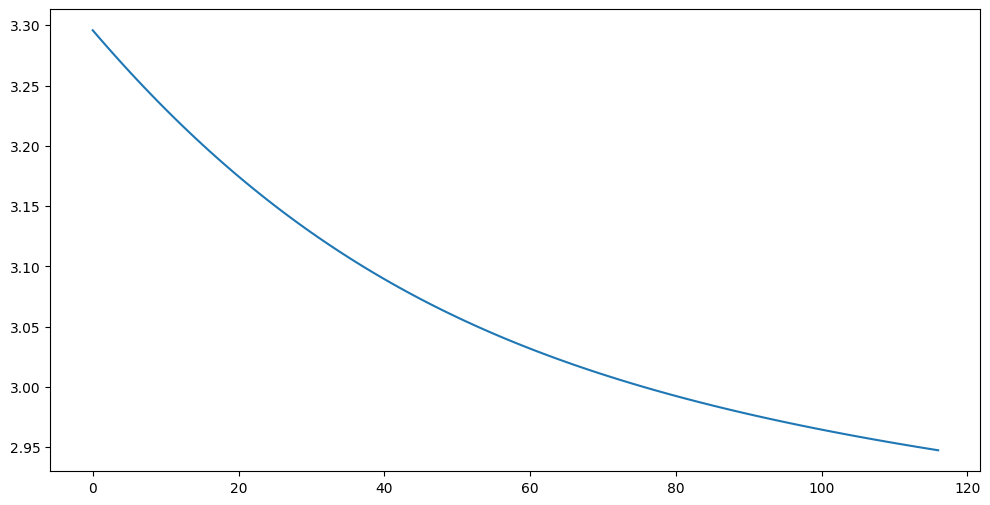

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(training_loss_history)
training_loss_history[-1]